## import dan load data

In [60]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

df: pd.DataFrame = pd.read_csv("../data/student_performance_clean.csv")
df.head()

,id_siswa,jenis_kelamin,jam_belajar_per_hari,presentase_kehadiran,nilai_tugas,nilai_UTS,nilai_UAS,nilai_partisipasi,akses_internet,kelas_tambahan,pendidikan_orang_tua,jam_tidur,nilai_keseluruhan,nilai
0,100000,1,4.54,69.98,36.47,70.70,53.10,17.96,1,0,2,8.09,52.3480,0.0
1,100001,0,5.26,84.80,34.25,27.92,87.17,11.29,0,1,1,4.73,53.9485,0.0
2,100002,1,8.69,73.76,72.29,70.92,99.61,76.10,0,1,3,8.73,82.0375,2.0
3,100003,1,4.06,45.00,97.63,31.73,88.85,33.55,0,0,1,8.22,66.4110,1.0
4,100004,1,8.83,51.13,65.19,78.28,54.23,88.99,0,0,1,8.59,65.6005,1.0


## split data

In [68]:
df = df.drop(columns=[
    'nilai_tugas',
    'nilai_UTS',
    'nilai_UAS',
    'nilai_partisipasi'
])
X = df.drop(columns=['nilai'])
y = df['nilai']

X_train,X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X.columns)

Index(['id_siswa', 'jenis_kelamin', 'jam_belajar_per_hari',
       'presentase_kehadiran', 'akses_internet', 'kelas_tambahan',
       'pendidikan_orang_tua', 'jam_tidur', 'nilai_keseluruhan'],
      dtype='str')


## scaling data

In [62]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train.shape)

(7951, 13)


## training dan prediksi model

In [63]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## eval model

In [65]:
print(f"MAE{mean_absolute_error(y_test, y_pred)}")
print(f"MSE{mean_squared_error(y_test, y_pred)}")
print(f"R2S{r2_score(y_test, y_pred)}")

MAE6.061773037470473e-15
MSE7.969241112542567e-29
R2S1.0


In [58]:
df[['nilai', 'nilai_tugas', 'nilai_UAS', 'nilai_UTS']].corr()

print(f"xtrain:{X_train.shape}")
print(f"xtest:{X_test.shape}")

xtrain:(7951, 13)
xtest:(1988, 13)


## visualisasikan

/home/vyubuntu/project_/venv_python/lib/python3.12/site-packages/seaborn/utils.py:105: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scout = method(scout_x, scout_y, **kws)
/home/vyubuntu/project_/venv_python/lib/python3.12/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


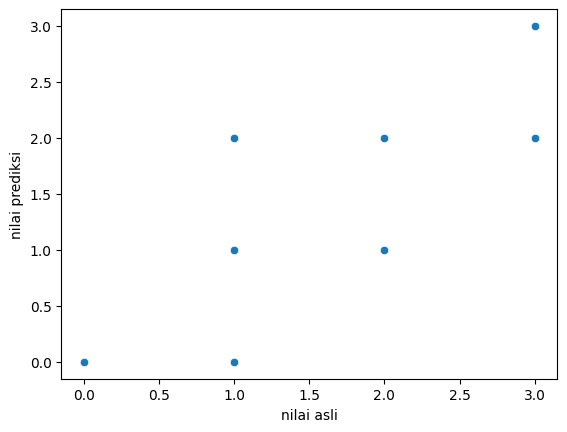

In [31]:
sns.scatterplot(x=y_test, y=y_pred, cmap='coolwarm')
plt.xlabel("nilai asli")
plt.ylabel("nilai prediksi")
plt.show()

In [66]:
import numpy as np

print(np.allclose(y_test, y_pred))

True
